# Классификация животных на изображениях


Базовый вариант решения третьего домашнего задания: задача многоклассовой классификации изображений

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/04_transfer_learning/pytorch/animals.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



# Импорт библиотек


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import pandas as pd

from torchvision.transforms import ToTensor, ToPILImage, Normalize, Compose
from torch.utils.data import DataLoader
import numpy as np
import random

import io
import os
from tqdm import tqdm

from PIL import Image
%matplotlib inline

# Загрузка данных

In [ ]:
!wget https://www.dropbox.com/scl/fi/ujneuteydjf2rekrcrsrv/train.zip?rlkey=eisyrf0d7pqchalienoag4iut&dl=1

--2025-05-24 04:48:04--  https://www.dropbox.com/scl/fi/ujneuteydjf2rekrcrsrv/train.zip?rlkey=eisyrf0d7pqchalienoag4iut
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc4a01a39503045f5874a0ca213f.dl.dropboxusercontent.com/cd/0/inline/CqSCkoQKy_LJmsvUVAqbYDRK8_of9w9HMNUTdY7iBABFa8AC9aT2Ukn_6zC1AM8qJb51jiMhasy7pwYN8eC5l6zInKaDzsDu7rMIYdl83aLhna3TpG8wJYaXAETv9sHq-S4/file# [following]
--2025-05-24 04:48:04--  https://uc4a01a39503045f5874a0ca213f.dl.dropboxusercontent.com/cd/0/inline/CqSCkoQKy_LJmsvUVAqbYDRK8_of9w9HMNUTdY7iBABFa8AC9aT2Ukn_6zC1AM8qJb51jiMhasy7pwYN8eC5l6zInKaDzsDu7rMIYdl83aLhna3TpG8wJYaXAETv9sHq-S4/file
Resolving uc4a01a39503045f5874a0ca213f.dl.dropboxusercontent.com (uc4a01a39503045f5874a0ca213f.dl.dropboxusercontent.com)... 162.125.2.15, 2620:100:6017:15::a27d:20f
Connecting to uc4a01a395

In [ ]:
!wget https://www.dropbox.com/scl/fi/z6tfzjblwok0n58l7xta1/test.zip?rlkey=ssrwcvdank0h17ce8fvobqofg&dl=1

--2025-05-24 04:48:13--  https://www.dropbox.com/scl/fi/z6tfzjblwok0n58l7xta1/test.zip?rlkey=ssrwcvdank0h17ce8fvobqofg
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uca33d689a9407e9b09865f85244.dl.dropboxusercontent.com/cd/0/inline/CqSNntUDq6E4LZ15fnTQrIetToa3rKje6AOyyw9MB-idLHFxBiAQoS_L26opYd2dFNOyiBz3Djo-Pnqv_2wOLa2F_jncasXyWtusLJL05_jF2GzBe5EsuAln9qeSpLv-PvE/file# [following]
--2025-05-24 04:48:13--  https://uca33d689a9407e9b09865f85244.dl.dropboxusercontent.com/cd/0/inline/CqSNntUDq6E4LZ15fnTQrIetToa3rKje6AOyyw9MB-idLHFxBiAQoS_L26opYd2dFNOyiBz3Djo-Pnqv_2wOLa2F_jncasXyWtusLJL05_jF2GzBe5EsuAln9qeSpLv-PvE/file
Resolving uca33d689a9407e9b09865f85244.dl.dropboxusercontent.com (uca33d689a9407e9b09865f85244.dl.dropboxusercontent.com)... 162.125.66.15, 2620:100:6017:15::a27d:20f
Connecting to uca33d689a

In [ ]:
#↓ "распакуй" + имя архива
!unzip train.zip?rlkey=eisyrf0d7pqchalienoag4iut
!unzip test.zip?rlkey=ssrwcvdank0h17ce8fvobqofg

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: train/OIP-sWdoGTEne-VxOOb0CFyG4AHaF6.jpeg  
  inflating: train/OIP-SWDYgp3tI2T7Qr5_rcNNEAHaGh.jpeg  
  inflating: train/OIP-swEKT8Sz_nQGx9kRmdsSLgHaD4.jpeg  
  inflating: train/OIP-sWepSeSdZ9bvAD0pArPuMwHaFj.jpeg  
  inflating: train/OIP-sWfqHzf55NJwv9ywLCCVagHaFj.jpeg  
  inflating: train/OIP-sWhAckYnDojjraKjmAeQWgHaDf.jpeg  
  inflating: train/OIP-SwibBPTOj-GPpSOKTY4vIwHaE8.jpeg  
  inflating: train/OIP-sWigzZFTi6jVbUUOxrq76gAAAA.jpeg  
  inflating: train/OIP-SwImWmKyyyHZnpuR_LWN5wHaHa.jpeg  
  inflating: train/OIP-SWjYhAhITa-eR8AMFE4fUwEsDl.jpeg  
  inflating: train/OIP-SWlf-2DtCqcr8nijYmeTpQHaEo.jpeg  
  inflating: train/OIP-sWM1GRzOggumOL_NEPOsAgHaGN.jpeg  
  inflating: train/OIP-swmhve0QW3mM44BRnYPWQgHaFj.jpeg  
  inflating: train/OIP-SwOALSvcbYgWQDGNh5EdaAHaD4.jpeg  
  inflating: train/OIP-sWPXA7isJcfZ9gtd-8U7uwHaFj.jpeg  
  inflating: train/OIP-swq3FzBcTnhf3bqMomKoxQHaE7.jpeg  
  inflating: train/O

Загрузим текстовые файлы в которых перечислены названия файлов и метки классов (для тренировочной выборки)

In [ ]:
!wget https://raw.githubusercontent.com/dayekb/mpti_ml/main/competition2/train.csv

--2025-05-24 04:48:30--  https://raw.githubusercontent.com/dayekb/mpti_ml/main/competition2/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 904495 (883K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>] 883.30K  --.-KB/s    in 0.04s   

2025-05-24 04:48:30 (20.7 MB/s) - ‘train.csv’ saved [904495/904495]



In [ ]:
train = pd.read_csv('train.csv', sep=',', index_col=0)
train

,label
id,
abdu-rahman-2934-unsplash.jpg,0
anete-lusina-609858-unsplash.jpg,0
anselmo-stevin-laksito-387930-unsplash.jpg,0
cat-mapper-max-ogden-204436-unsplash.jpg,0
cel-lisboa-73965-unsplash.jpg,0
...,...
OIP-Wu_4fQ30ezKIJMuFs6KuvAHaEM.jpeg,7
OIP-wu_w7ncADQ9Vh5QqcCCXbgHaE8.jpeg,8
OIP--wuFK6RSOflCu9IAOxIyugHaE8.jpeg,8


В файле submission представлены названия файлов для тестовой выборки. метки классов заполнены нулями

In [ ]:
!wget https://raw.githubusercontent.com/dayekb/mpti_ml/main/competition2/submission.csv

--2025-05-24 04:48:30--  https://raw.githubusercontent.com/dayekb/mpti_ml/main/competition2/submission.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 92980 (91K) [text/plain]
Saving to: ‘submission.csv’

submission.csv      100%[===================>]  90.80K  --.-KB/s    in 0.01s   

2025-05-24 04:48:31 (6.41 MB/s) - ‘submission.csv’ saved [92980/92980]



In [ ]:
submission = pd.read_csv('submission.csv', sep=',', index_col=0)
submission

,label
id,
ee32b90c29f11c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
ee33b00e2ee90021d85a5854ee454296eb70e3c818b413449df1c17fa2ee_640.jpg,0
ee37b70620fd1c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ee3cb70b2bf31c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ef31b80e2ef01c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
...,...
q-aila-162475-unsplash.jpg,0
sam-burriss-378658-unsplash.jpg,0
sarah-dorweiler-128578-unsplash.jpg,0


Определяем инструмент предварительной обработки изображений из набора данных

Добавляется строка

`transforms.Lambda(lambda x: x[:3])`

которая нужна для того чтобы трансформировать некоторые 4-х канальные изображения из выборки в 3-х канальные

In [ ]:
my_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x[:3]),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

Создадим свой класс для загрузки данных из папки

Наследуем от `Dataset`

Особенности написанного класса

* считываются все изображения в папке `img_dir` по индексам, обозначенным в файле `txt_path` (`samples`)
* из файла `txt_path` также берутся метки классов (`target`)

In [ ]:
class CustomDataSet(Dataset):
    def __init__(self, txt_path='/content/train.csv', img_dir='/content/train',
                 transform=None, test=False):
        df = pd.read_csv(txt_path, sep=',', index_col=0)
        self.img_names = df.index.values
        self.df = df
        self.txt_path = txt_path
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def get_image_from_folder(self, name):

        image = Image.open(os.path.join(self.img_dir, name))
        return image

    def __getitem__(self, idx):
        sample = self.get_image_from_folder(self.img_names[idx])
        if self.transform is not None:
            sample = self.transform(sample)
        target = self.df.label[idx]
        return sample, target

Выполним загрузку данных в два этапа



1. Создадим экземпляр класса `CustomDataSet`, указав
* путь к файлу с целевыми метками и названием тренировочных файлов
* путь к папке с тренировочными данными
* инструмент предварительной обработки

In [ ]:
train_dataset = CustomDataSet(txt_path='/content/train.csv',
                             img_dir='/content/train',
                             transform=my_transforms)

2. Создадим загрузчик данных, используя созданный ранее экземпляр класса `CustomDataSet`

In [ ]:
batch_size = 64

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=2,
                          )

Имена классов

In [ ]:
classes = ['кошка', 'слон', 'бабочка', 'овца',
           'паук', 'лошадь', 'собака', 'корова',
           'курица', 'белка']

Просматриваем примеры изображений

<ipython-input-10-1d511502da77>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = self.df.label[idx]
<ipython-input-10-1d511502da77>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = self.df.label[idx]


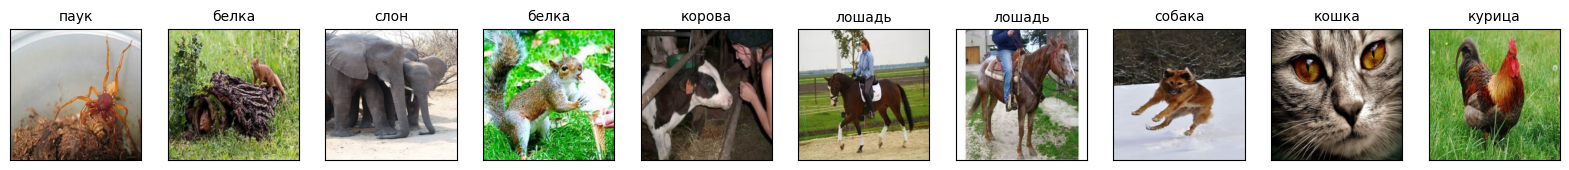

In [ ]:
nsamples=10

imgs, label = next(iter(train_loader))

fig=plt.figure(figsize=(20,10),facecolor='w')
for i in range(nsamples):
    ax = plt.subplot(1,nsamples, i+1)
    img = imgs[i] / 2 + 0.5     # обратная нормализация
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(classes[label[i]], fontsize=10)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Создаем модель




In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [ ]:
device

'cuda'

Загружаем предварительно обученную модель

In [ ]:
resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


Добавляем новый классификатор нашего набора данных

In [ ]:
resnet.fc = nn.Sequential(
                         nn.Linear(resnet.fc.in_features, 32),
                         nn.ReLU(),
                         nn.Linear(32, 10))

Передаем модель на устройство

In [ ]:
model = resnet.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Обучаем модель

Задаем функцию ошибки - категориальная перекрестная энтропия



In [ ]:
loss_fn = nn.CrossEntropyLoss()

Задаем оптимизатор

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Определяем функцию для обучения нейронной сети



In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Включаем режим обучения
    model.train()
    # В цикле получаем все мини-выборки
    # X - изображение
    # y - номер класса
    for batch, (X, y) in enumerate(dataloader):
        # Передаем данные на устройство
        X, y = X.to(device), y.to(device)
        # Обнуляем значения градиента
        optimizer.zero_grad()

        # Расчитываем данные на выходе из нейронной сети
        pred = model(X)

        # Расчитываем значение ошибки
        loss = loss_fn(pred, y)

        # Обратное распространение ошиби
        loss.backward()

        # Выполняем шаг обучения (изменение весов)
        optimizer.step()

        # Печатаем прогресс каждые 50 мини-выборок
        if batch % 50 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Ошибка: {loss:>7f}  [{current:>5d}/{size:>5d}]")

Обучаем модель в течение 2 эпох



In [ ]:
epochs = 2
for t in range(epochs):
    print(f"Эпоха {t+1}\n-------------------------------")
    # Обучение модели
    train(train_loader, model, loss_fn, optimizer)
print("Обучение завершено!")

Эпоха 1
-------------------------------


<ipython-input-10-1d511502da77>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = self.df.label[idx]
<ipython-input-10-1d511502da77>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = self.df.label[idx]


Ошибка: 2.387795  [   64/21949]
Ошибка: 0.696414  [ 3264/21949]
Ошибка: 0.628336  [ 6464/21949]
Ошибка: 0.339536  [ 9664/21949]
Ошибка: 0.338487  [12864/21949]
Ошибка: 0.507176  [16064/21949]


## Распознавание изображений из тестового набора данных



Включаем режим оценки качества модели

In [ ]:
model.eval()

Создадим загрузчик для тестовых данных, на которых вам надо будет сделать предсказание

In [ ]:
test_dataset = CustomDataSet(txt_path='/content/submission.csv',
                             img_dir='/content/test',
                             transform=my_transforms)


Важно - данные в этом случае не надо перемешивать, поскольку при загрузке файла с ответом необходим строгий порядок

In [ ]:
test_loader = DataLoader(dataset=test_dataset,
                          batch_size=64,
                          shuffle=False
                          )

Реализуем предсказание модели на тестовых данных

In [ ]:
test_predictions = []

for inputs, _ in tqdm(test_loader):
    inputs = inputs.to(device)
    with torch.set_grad_enabled(False):
        preds = model(inputs)
    test_predictions.append(preds.argmax(dim = 1).data.cpu().numpy())

test_predictions = np.concatenate(test_predictions)


Откроем файл для загрузки (предсказания заполнены нулями)

In [ ]:
test_predictions[:100]

In [ ]:
submission

Поместим в файл предсказания модели

In [ ]:
submission.label = test_predictions
submission

## Готовим итоговый файл

In [ ]:
submission.to_csv('/content/ResNet18_Submission.csv',
                  index=True, sep = ',')

# Идеи для улучшения результата

* Увеличение числа эпох
* Изменение числа нейронов в полносвязном слое
* Использование ResNet с большим количеством слоем ([список реализаций ResNet в PyTorch](https://pytorch.org/hub/pytorch_vision_resnet/)).
* Использование других [предобученных архитектур](https://pytorch.org/vision/main/models.html), таких как EfficientNet, Inception и т.п.
* Расширение выборки за счет аугментации данных